## **ONLINE RETAIL DATASET EDA**

### **Mounting the Drive**

In [114]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Importing Libraries**



In [115]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

### **Loading Dataset**

In [116]:
df = pd.read_excel('/content/drive/MyDrive/Online Retail Dataset.xlsx')
df.head()
display(df)

,Invoice No,Stock Code,Description,Quantity,Invoice Date,Unit Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


### **Basic Overview**

In [117]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice No    541909 non-null  object        
 1   Stock Code    541909 non-null  object        
 2   Description   540455 non-null  object        
 3   Quantity      541909 non-null  int64         
 4   Invoice Date  541909 non-null  datetime64[ns]
 5   Unit Price    541909 non-null  float64       
 6   Customer ID   406829 non-null  float64       
 7   Country       541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,Invoice Date,Unit Price,Customer ID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### **Checking Missing Values**

In [118]:
df.isnull().sum()

,0
Invoice No,0
Stock Code,0
Description,1454
Quantity,0
Invoice Date,0
Unit Price,0
Customer ID,135080
Country,0


### **Cleaning Dataset**

In [119]:
# Checking duplicates
df.duplicated().sum()

# Removing exact duplicate rows
df = df.drop_duplicates()

# Removing only true duplicates
df = df.drop_duplicates(subset=[
    'Invoice No', 'Stock Code', 'Invoice Date', 'Customer ID'
])

# Removing cancelled transactions
df['Invoice No'].astype(str).str.startswith('C').sum()

# Removing negative or zero quantity
df = df[df['Quantity'] > 0]

# Removing negative or zero price
df = df[df['Unit Price'] > 0]

# Removing missing values for Description
df = df.dropna(subset=['Description'])

### **Checking Unique Values**

In [120]:
df.nunique()

,0
Invoice No,19959
Stock Code,3922
Description,4026
Quantity,375
Invoice Date,18498
Unit Price,1274
Customer ID,4338
Country,38


### **Creating Two Datasets**

In [121]:
# Full dataset (KEEP missing Customer ID for Sales Analysis)
df_full = df.copy()

# Customer dataset (REMOVE missing Customer ID for Customer Analysis)
df_customers = df.dropna(subset=['Customer ID']).copy()

### **Fixing Data Types**

In [122]:
# Converting after cleaning
df_full['Customer ID'] = df_full['Customer ID'].astype('Int64').astype(str)
df_customers['Customer ID'] = df_customers['Customer ID'].astype('Int64').astype(str)

### **Featuring Engineering**

In [123]:
# Creating Revenue
df_full['Revenue'] = df_full['Quantity'] * df_full['Unit Price']
df_customers['Revenue'] = df_customers['Quantity'] * df_customers['Unit Price']

# Time features
for df_ in [df_full, df_customers]:
    df_['Year'] = df_['Invoice Date'].dt.year
    df_['Month'] = df_['Invoice Date'].dt.to_period('M')
    df_['Month_Name'] = df_['Invoice Date'].dt.month_name()
    df_['Day'] = df_['Invoice Date'].dt.day
    df_['Hour'] = df_['Invoice Date'].dt.hour
    df_['DayOfWeek'] = df_['Invoice Date'].dt.day_name()

### **Basic Observations and Calculations**

In [124]:
df_full.info()
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 519589 entries, 0 to 541908
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice No    519589 non-null  object        
 1   Stock Code    519589 non-null  object        
 2   Description   519589 non-null  object        
 3   Quantity      519589 non-null  int64         
 4   Invoice Date  519589 non-null  datetime64[ns]
 5   Unit Price    519589 non-null  float64       
 6   Customer ID   519589 non-null  object        
 7   Country       519589 non-null  object        
 8   Revenue       519589 non-null  float64       
 9   Year          519589 non-null  int32         
 10  Month         519589 non-null  period[M]     
 11  Month_Name    519589 non-null  object        
 12  Day           519589 non-null  int32         
 13  Hour          519589 non-null  int32         
 14  DayOfWeek     519589 non-null  object        
dtypes: datetime64[ns](1), 

In [125]:
# Average Order Value (AOV)
order_value = df_full.groupby('Invoice No')['Revenue'].sum()

AOV = order_value.mean()
print("Average Order Value:", AOV)

Average Order Value: 530.4415022295706


In [126]:
# Most Common Value (Mode) for All Columns

mode_table = pd.DataFrame(columns=['Column', 'Most Common Value', 'Frequency'])

for col in df_full.columns:
    mode_val = df_full[col].mode()[0]
    freq = df_full[col].value_counts().iloc[0]

    mode_table.loc[len(mode_table)] = [col, mode_val, freq]

mode_table

,Column,Most Common Value,Frequency
0,Invoice No,573585,1110
1,Stock Code,85123A,2198
2,Description,WHITE HANGING HEART T-LIGHT HOLDER,2256
3,Quantity,1,142758
4,Invoice Date,2011-10-31 14:41:00,1110
5,Unit Price,1.25,48262
6,Customer ID,<NA>,131745
7,Country,United Kingdom,474808
8,Revenue,15.0,20170
9,Year,2011,479071


### **Initial Summary and Comparison Table**

In [127]:
# A. Full Dataset Summary

total_orders_full = df_full['Invoice No'].nunique()
aov_full = df_full.groupby('Invoice No')['Revenue'].sum().mean()
total_quantity_full = df_full['Quantity'].sum()
avg_quantity_per_order_full = total_quantity_full / total_orders_full

print("Full Dataset Summary")
print(f"Total Orders (Full Data): {total_orders_full}")
print(f"Average Order Value (Full Data): {aov_full:.2f}")
print(f"Total Quantity Sold (Full Data): {total_quantity_full}")
print(f"Average Quantity per Order (Full Data): {avg_quantity_per_order_full:.2f}")
print("\n")

# B. Customer Dataset Summary

total_orders_customer = df_customers['Invoice No'].nunique()
aov_customer = df_customers.groupby('Invoice No')['Revenue'].sum().mean()
total_quantity_customer = df_customers['Quantity'].sum()
avg_quantity_per_order_customer = total_quantity_customer / total_orders_customer

print("Customer Dataset Summary")
print(f"Total Orders (Customer Data): {total_orders_customer}")
print(f"Average Order Value (Customer Data): {aov_customer:.2f}")
print(f"Total Quantity Sold (Customer Data): {total_quantity_customer}")
print(f"Average Quantity per Order (Customer Data): {avg_quantity_per_order_customer:.2f}")
print("\n")

# C. Combined Dataset Summary

print("Online Retail Dataset Summary")
comparison_detailed = pd.DataFrame({
    'Metric': [
        'Total Orders',
        'Average Order Value',
        'Total Quantity Sold',
        'Average Quantity per Order'
    ],
    'Full Data': [
        total_orders_full,
        aov_full,
        total_quantity_full,
        avg_quantity_per_order_full
    ],
    'Customer Data': [
        total_orders_customer,
        aov_customer,
        total_quantity_customer,
        avg_quantity_per_order_customer
    ]
})

print(comparison_detailed)
print("\n")

# D. Initial Comparison Table

print("Online Retail Dataset Comparison Table")
starting_comparison = pd.DataFrame({
    'Metric': [
        'Rows',
        'Transactions',
        'Unique Customers',
        'Unique Products',
        'Countries',
        'Total Revenue'
    ],
    'Full Dataset': [
        df_full.shape[0],
        df_full['Invoice No'].nunique(),
        df_full['Customer ID'].nunique(),
        df_full['Stock Code'].nunique(),
        df_full['Country'].nunique(),
        df_full['Revenue'].sum()
    ],
    'Customer Dataset': [
        df_customers.shape[0],
        df_customers['Invoice No'].nunique(),
        df_customers['Customer ID'].nunique(),
        df_customers['Stock Code'].nunique(),
        df_customers['Country'].nunique(),
        df_customers['Revenue'].sum()
    ]
})

starting_comparison

Full Dataset Summary
Total Orders (Full Data): 19959
Average Order Value (Full Data): 530.44
Total Quantity Sold (Full Data): 5546556
Average Quantity per Order (Full Data): 277.90


Customer Dataset Summary
Total Orders (Customer Data): 18531
Average Order Value (Customer Data): 477.28
Total Quantity Sold (Customer Data): 5128601
Average Quantity per Order (Customer Data): 276.76


Online Retail Dataset Summary
                       Metric     Full Data  Customer Data
0                Total Orders  1.995900e+04   1.853100e+04
1         Average Order Value  5.304415e+02   4.772837e+02
2         Total Quantity Sold  5.546556e+06   5.128601e+06
3  Average Quantity per Order  2.778975e+02   2.767579e+02


Online Retail Dataset Comparison Table


,Metric,Full Dataset,Customer Dataset
0,Rows,5.195890e+05,387844.000
1,Transactions,1.995900e+04,18531.000
2,Unique Customers,4.339000e+03,4338.000
3,Unique Products,3.922000e+03,3665.000
4,Countries,3.800000e+01,37.000
5,Total Revenue,1.058708e+07,8844544.403


### **Outlier Boxplots**

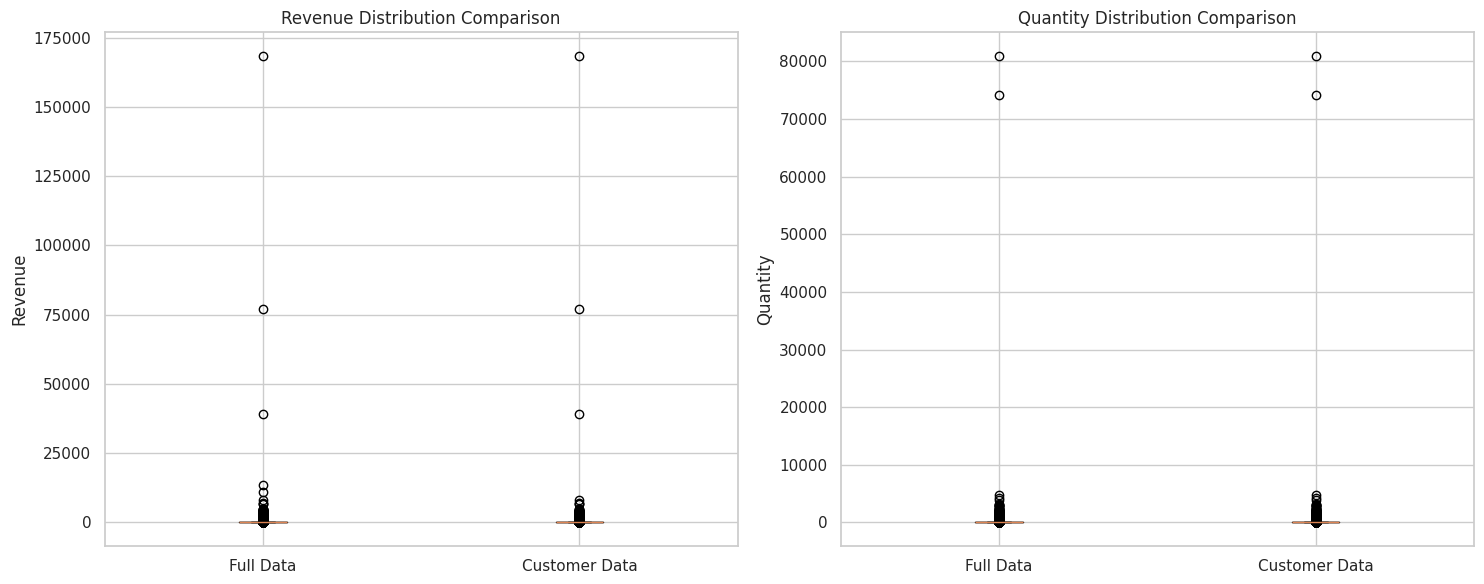

In [128]:
# Revenue and Quantity Distribution Comparison using Boxplot to identify Outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# First subplot: Revenue Distribution Comparison
axes[0].boxplot([df_full['Revenue'], df_customers['Revenue']],
            tick_labels=['Full Data', 'Customer Data'])
axes[0].set_title("Revenue Distribution Comparison")
axes[0].set_ylabel("Revenue")

# Second subplot: Quantity Distribution Comparison
axes[1].boxplot([df_full['Quantity'], df_customers['Quantity']],
            tick_labels=['Full Data', 'Customer Data'])
axes[1].set_title("Quantity Distribution Comparison")
axes[1].set_ylabel("Quantity")

plt.tight_layout()
plt.show()

### **Univariate Analysis**

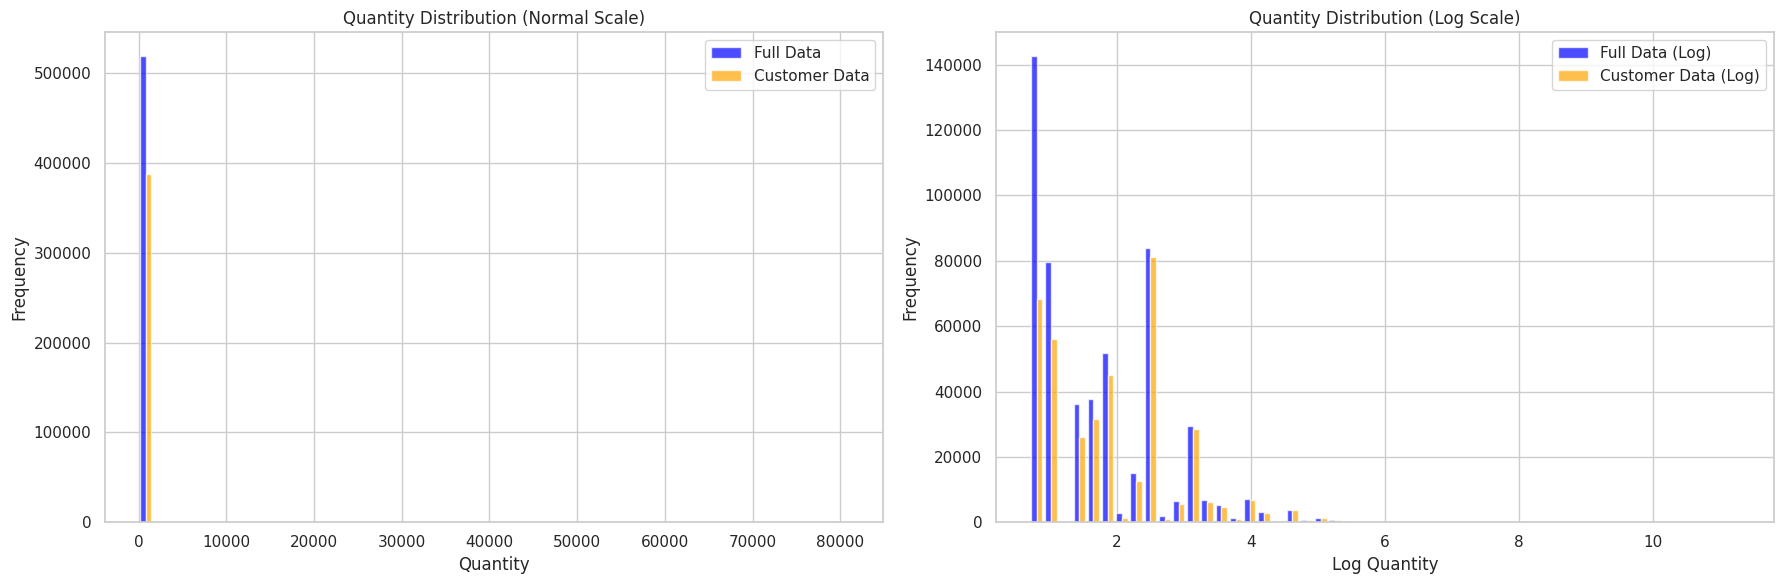

In [129]:
# Quantity Distribution (Normal vs Log) for both Full & Customer Datasets - Combined

fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Two subplots for normal and log comparison

# Normal Scale Comparison
axes[0].hist([df_full['Quantity'], df_customers['Quantity']], bins=50, alpha=0.7, label=['Full Data', 'Customer Data'], color=['blue', 'orange'])
axes[0].set_title("Quantity Distribution (Normal Scale)")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Log Scale Comparison
axes[1].hist([np.log1p(df_full['Quantity']), np.log1p(df_customers['Quantity'])], bins=50, alpha=0.7, label=['Full Data (Log)', 'Customer Data (Log)'], color=['blue', 'orange'])
axes[1].set_title("Quantity Distribution (Log Scale)")
axes[1].set_xlabel("Log Quantity")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

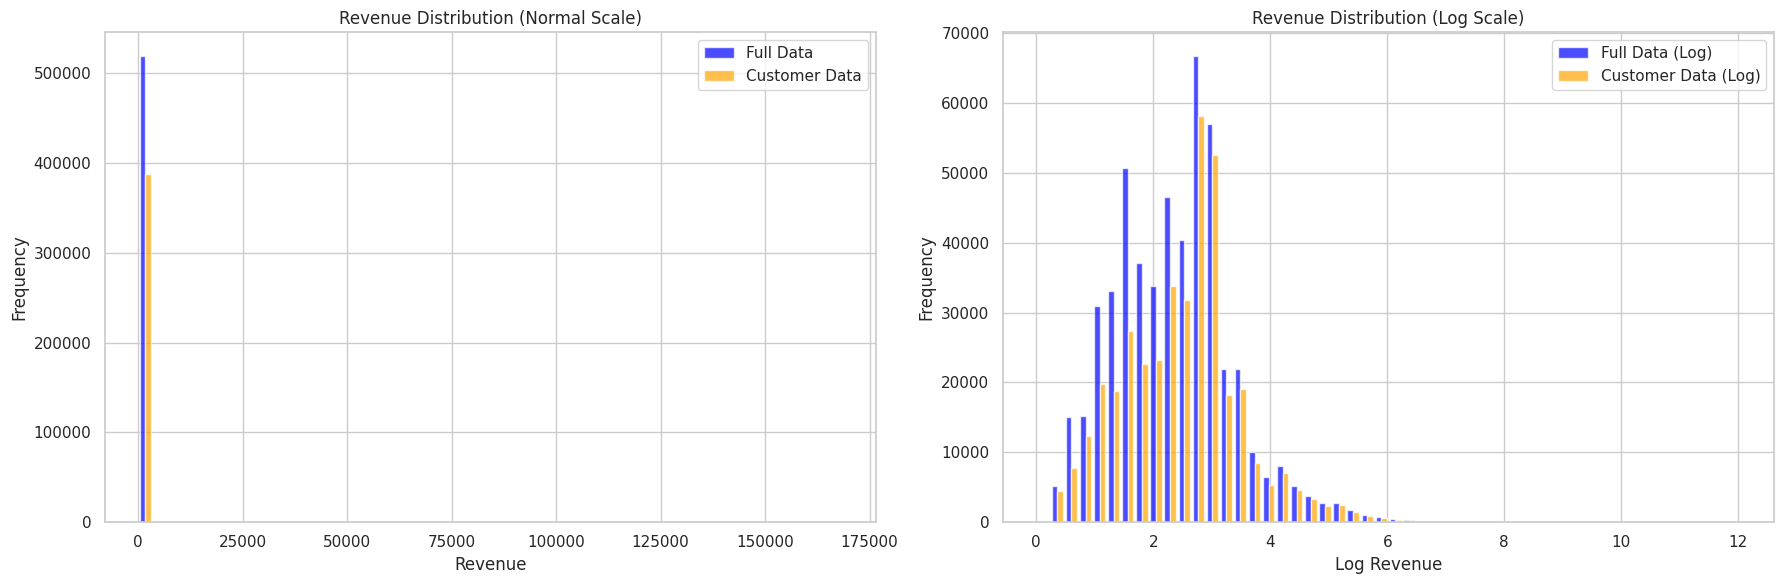

In [130]:
# Revenue Distribution (Normal vs Log) for both Full & Customer Datasets - Combined

fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Two subplots for normal and log comparison

# Normal Scale Comparison
axes[0].hist([df_full['Revenue'], df_customers['Revenue']], bins=50, alpha=0.7, label=['Full Data', 'Customer Data'], color=['blue', 'orange'])
axes[0].set_title("Revenue Distribution (Normal Scale)")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Log Scale Comparison
axes[1].hist([np.log1p(df_full['Revenue']), np.log1p(df_customers['Revenue'])], bins=50, alpha=0.7, label=['Full Data (Log)', 'Customer Data (Log)'], color=['blue', 'orange'])
axes[1].set_title("Revenue Distribution (Log Scale)")
axes[1].set_xlabel("Log Revenue")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

### **Bivariate Analysis**

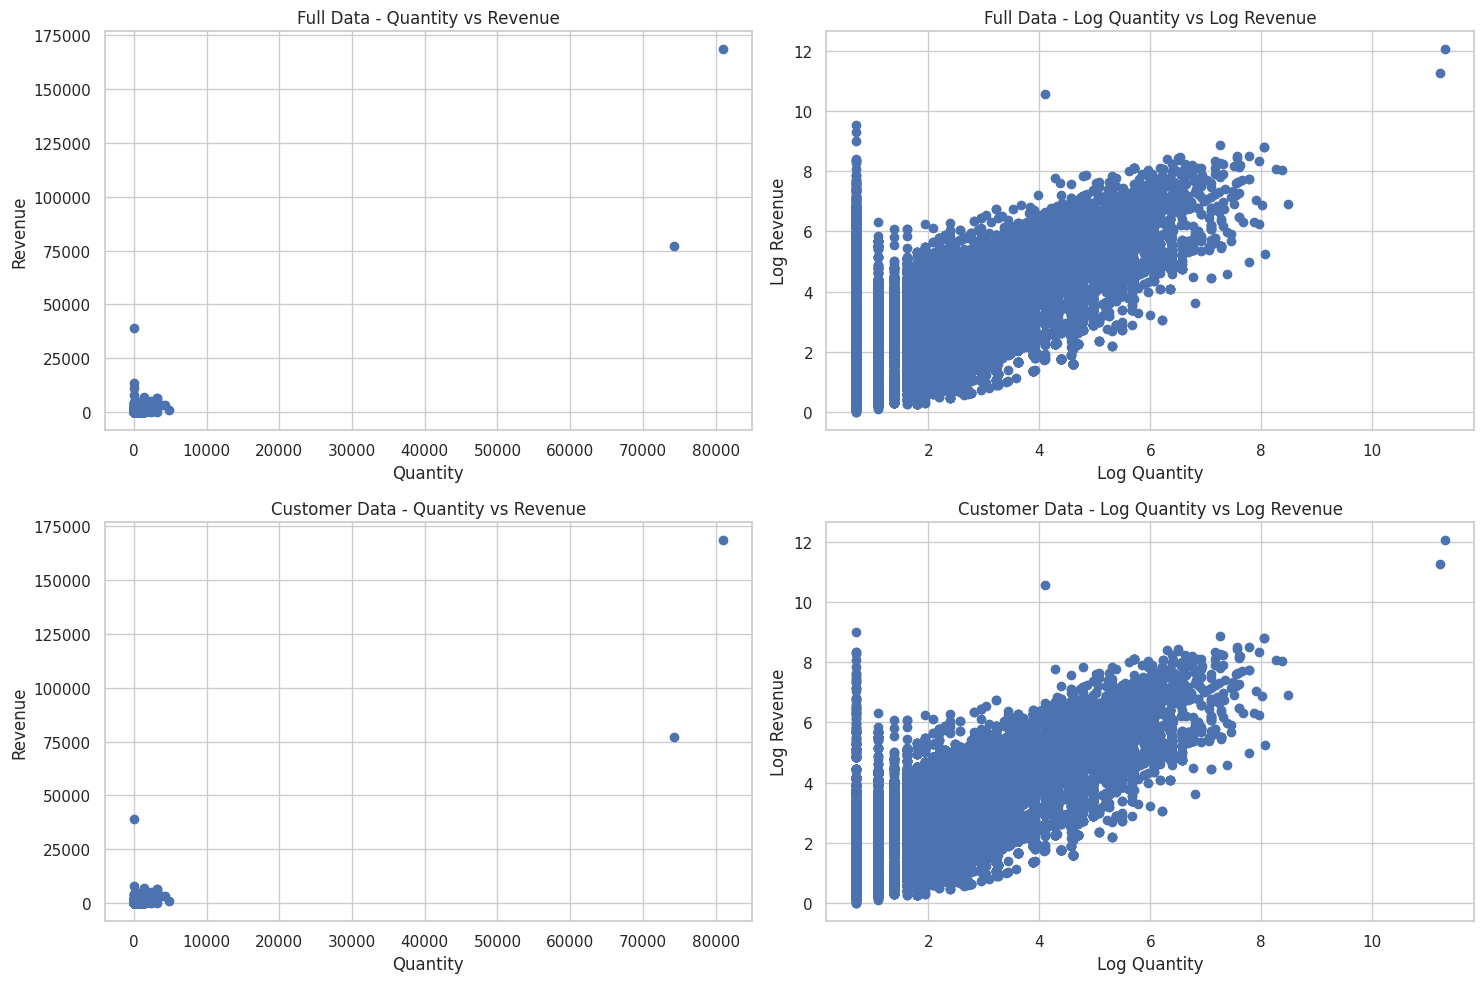

In [131]:
# Scatter Plot (Normal vs Log) for Quantity and Revenue
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# FULL DATA - NORMAL
axes[0,0].scatter(df_full['Quantity'], df_full['Revenue'])
axes[0,0].set_title("Full Data - Quantity vs Revenue")
axes[0,0].set_xlabel("Quantity")
axes[0,0].set_ylabel("Revenue")

# FULL DATA - LOG
axes[0,1].scatter(np.log1p(df_full['Quantity']), np.log1p(df_full['Revenue']))
axes[0,1].set_title("Full Data - Log Quantity vs Log Revenue")
axes[0,1].set_xlabel("Log Quantity")
axes[0,1].set_ylabel("Log Revenue")

# CUSTOMER DATA - NORMAL
axes[1,0].scatter(df_customers['Quantity'], df_customers['Revenue'])
axes[1,0].set_title("Customer Data - Quantity vs Revenue")
axes[1,0].set_xlabel("Quantity")
axes[1,0].set_ylabel("Revenue")

# CUSTOMER DATA - LOG
axes[1,1].scatter(np.log1p(df_customers['Quantity']), np.log1p(df_customers['Revenue']))
axes[1,1].set_title("Customer Data - Log Quantity vs Log Revenue")
axes[1,1].set_xlabel("Log Quantity")
axes[1,1].set_ylabel("Log Revenue")

plt.tight_layout()
plt.show()

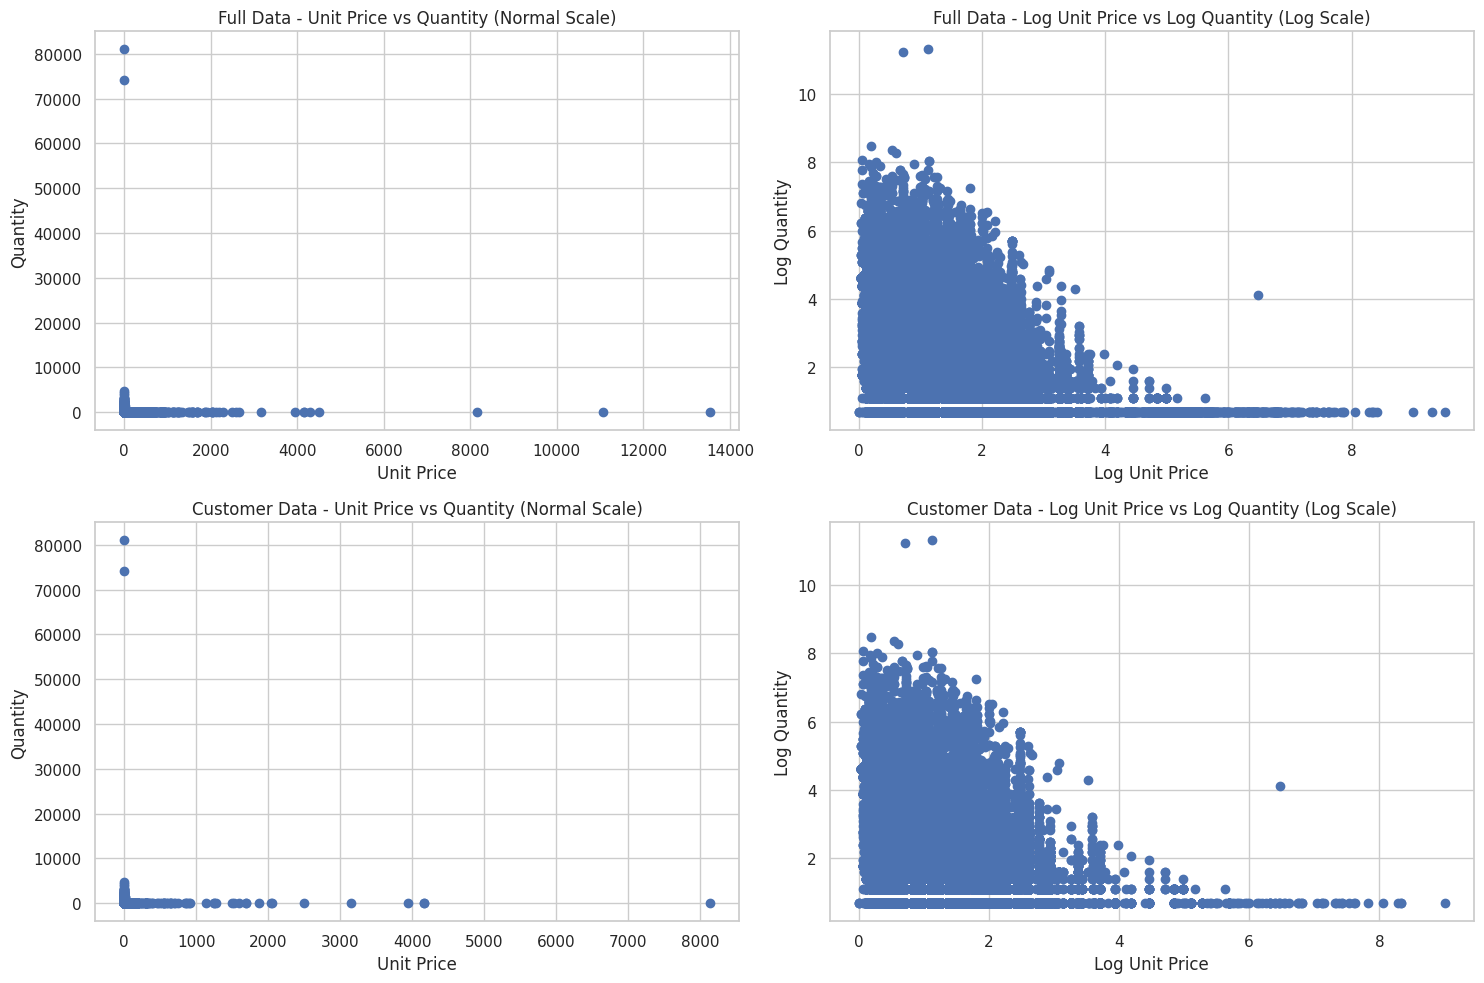

In [132]:
# Scatter Plot (Normal vs Log) for Quantity and Unit Price
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# FULL DATA - NORMAL
axes[0,0].scatter(df_full['Unit Price'], df_full['Quantity'])
axes[0,0].set_title("Full Data - Unit Price vs Quantity (Normal Scale)")
axes[0,0].set_xlabel("Unit Price")
axes[0,0].set_ylabel("Quantity")

# FULL DATA - LOG
axes[0,1].scatter(np.log1p(df_full['Unit Price']), np.log1p(df_full['Quantity']))
axes[0,1].set_title("Full Data - Log Unit Price vs Log Quantity (Log Scale)")
axes[0,1].set_xlabel("Log Unit Price")
axes[0,1].set_ylabel("Log Quantity")

# CUSTOMER DATA - NORMAL
axes[1,0].scatter(df_customers['Unit Price'], df_customers['Quantity'])
axes[1,0].set_title("Customer Data - Unit Price vs Quantity (Normal Scale)")
axes[1,0].set_xlabel("Unit Price")
axes[1,0].set_ylabel("Quantity")

# CUSTOMER DATA - LOG
axes[1,1].scatter(np.log1p(df_customers['Unit Price']), np.log1p(df_customers['Quantity']))
axes[1,1].set_title("Customer Data - Log Unit Price vs Log Quantity (Log Scale)")
axes[1,1].set_xlabel("Log Unit Price")
axes[1,1].set_ylabel("Log Quantity")

plt.tight_layout()
plt.show()

### **Value Counts and Count Plots**

Country
United Kingdom    474808
Germany             9013
France              8372
EIRE                7875
Spain               2463
Netherlands         2359
Belgium             2031
Switzerland         1945
Portugal            1477
Australia           1180
Name: count, dtype: int64


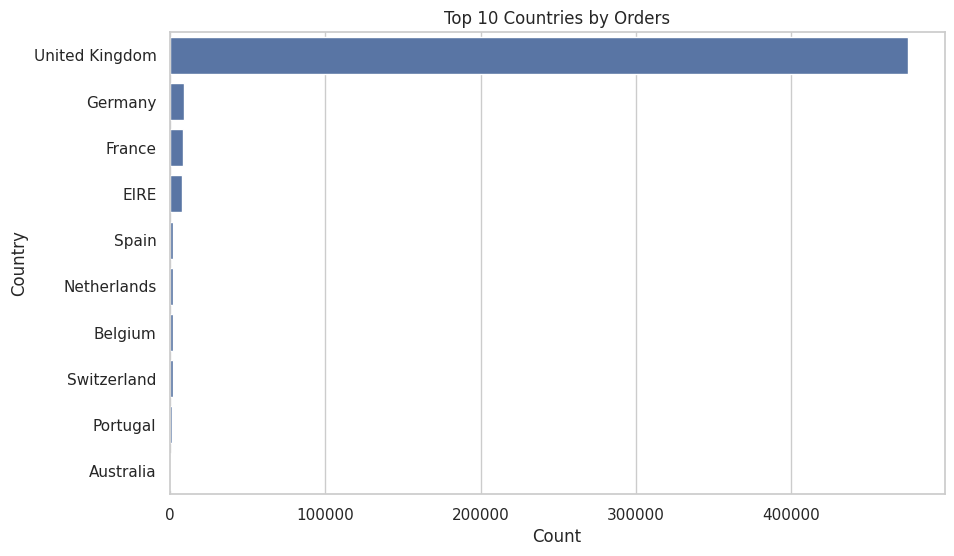

In [133]:
# Top 10 Countries by Orders
top_countries = df_full['Country'].value_counts().head(10)
print(top_countries)

sns.countplot(y='Country', data=df_full, order=top_countries.index)
plt.title("Top 10 Countries by Orders")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

DayOfWeek
Monday       91665.0
Tuesday      97938.0
Wednesday    90633.0
Thursday     99436.0
Friday       78972.0
Saturday         NaN
Sunday       60945.0
Name: count, dtype: float64


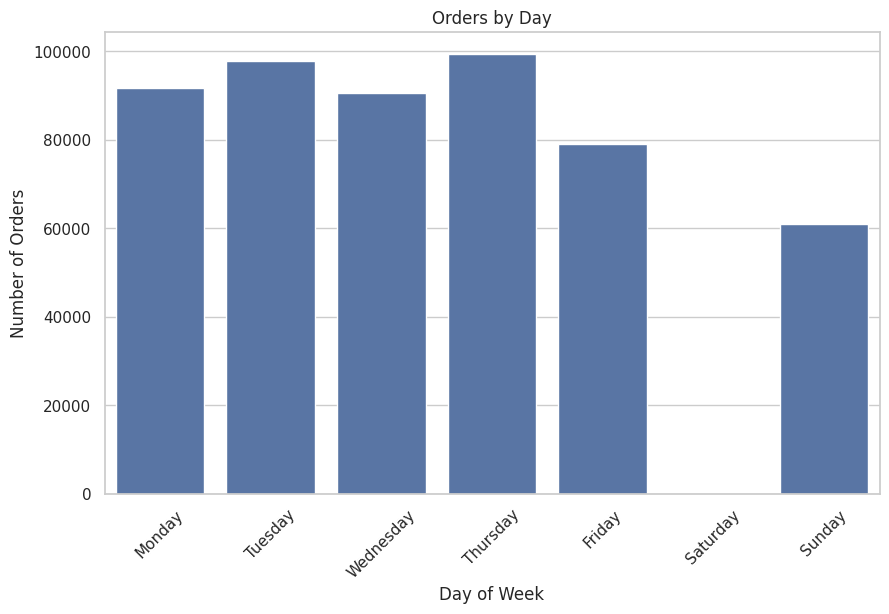

In [134]:
# Day-wise Orders
day_of_week_counts = df_full['DayOfWeek'].value_counts().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
print(day_of_week_counts)

sns.countplot(x='DayOfWeek', data=df_full,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.title("Orders by Day")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

### **Time Series Analysis**

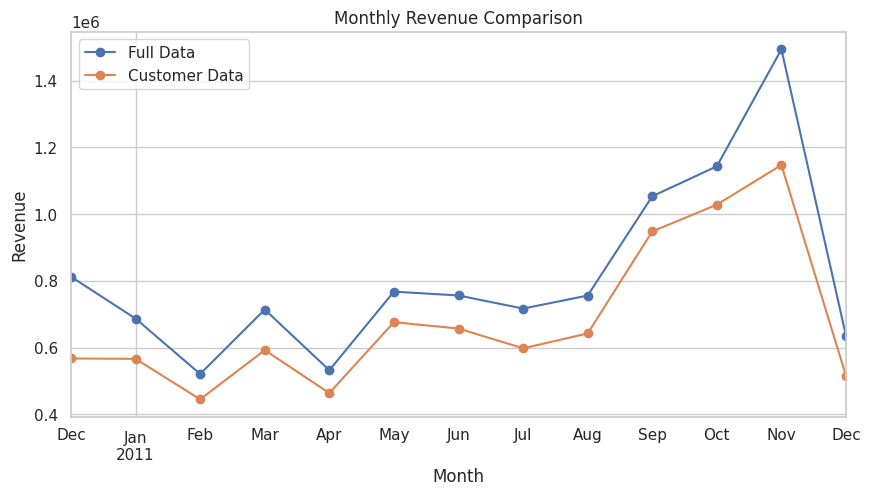

In [135]:
# Monthly Revenue Comparison

plt.figure(figsize=(10,5))

df_full.groupby('Month')['Revenue'].sum().plot(marker='o', label='Full Data')
df_customers.groupby('Month')['Revenue'].sum().plot(marker='o', label='Customer Data')

plt.title("Monthly Revenue Comparison")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()

plt.show()

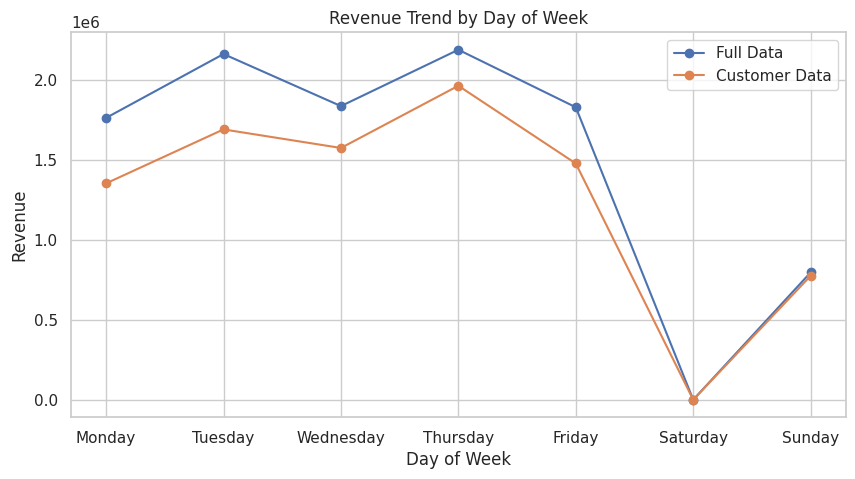

In [136]:
# Revenue by Day of the Week

# Revenue by Day for full dataset
rev_day_full = df_full.groupby('DayOfWeek')['Revenue'].sum()

# Revenue by Day for customer dataset
rev_day_customer = df_customers.groupby('DayOfWeek')['Revenue'].sum()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

rev_day_full = rev_day_full.reindex(day_order)
rev_day_customer = rev_day_customer.reindex(day_order)

plt.figure(figsize=(10,5))

plt.plot(rev_day_full.fillna(0), marker='o', label='Full Data')
plt.plot(rev_day_customer.fillna(0), marker='o', label='Customer Data')

plt.title("Revenue Trend by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.legend()

plt.show()

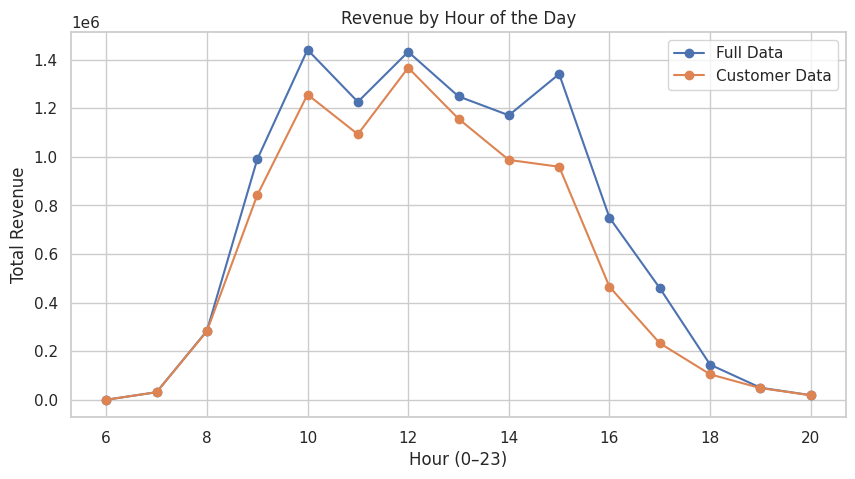

In [137]:
# Hourly Sales

# Extract hour
df_full['Hour'] = df_full['Invoice Date'].dt.hour
df_customers['Hour'] = df_customers['Invoice Date'].dt.hour

# Group
rev_hour_full = df_full.groupby('Hour')['Revenue'].sum()
rev_hour_customer = df_customers.groupby('Hour')['Revenue'].sum()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(rev_hour_full, marker='o', label='Full Data')
plt.plot(rev_hour_customer, marker='o', label='Customer Data')

plt.title("Revenue by Hour of the Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Total Revenue")
plt.legend()

plt.show()

### **Correlation Heatmap**

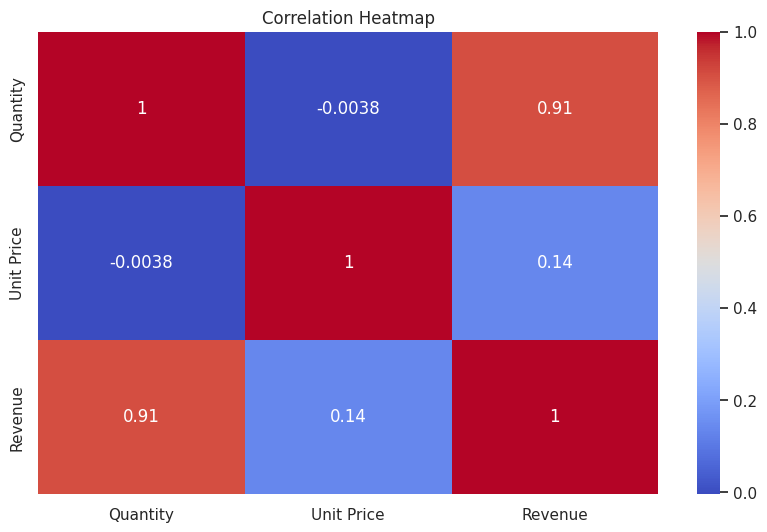

In [138]:
# Heatmap (Correlation) for Quantity, Unit Price and Revenue
corr = df_full[['Quantity','Unit Price','Revenue']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### **Crosstabs**

In [139]:
# Country vs Day of Week
ct = pd.crosstab(df_full['Country'], df_full['DayOfWeek'])
print(ct)

DayOfWeek             Friday  Monday  Sunday  Thursday  Tuesday  Wednesday
Country                                                                   
Australia                 98      55      52       388      269        318
Austria                   44     136      37        54      106         21
Bahrain                    0      14       0         4        0          0
Belgium                  495     199     149       504      329        355
Brazil                    32       0       0         0        0          0
Canada                     1     144       0         5        0          1
Channel Islands          102      83      68       151      133        210
Cyprus                   168     114       0       149       83         85
Czech Republic            10      15       0         0        0          0
Denmark                   11      73       0       184       12         99
EIRE                    1582    1633     516      1435     1318       1391
European Community       

In [140]:
# Average Revenue by Country and Day of Week
pivot = pd.pivot_table(df_full,
                       values='Revenue',
                       index='Country',
                       columns='DayOfWeek',
                       aggfunc='mean',
                       observed=False)

print(pivot.head())

DayOfWeek     Friday     Monday     Sunday    Thursday     Tuesday   Wednesday
Country                                                                       
Australia  42.631939  25.320727  33.537115  138.030902  120.914833  141.585000
Austria    22.221591  20.646250  15.860811   28.820926   24.283208   80.754286
Bahrain          NaN  47.510000        NaN   22.250000         NaN         NaN
Belgium    21.913111  20.766734  17.206711   20.609147   19.227325   19.549775
Brazil     35.737500        NaN        NaN         NaN         NaN         NaN


### **Product Analysis**

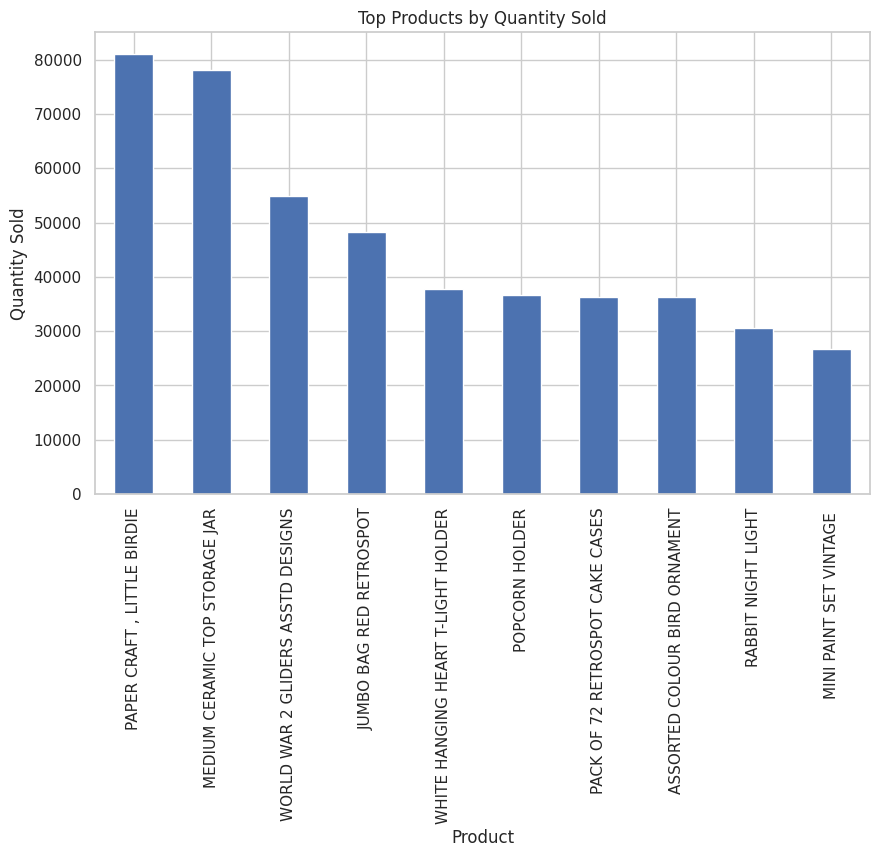

In [141]:
# Top 10 Products by Quantity
top_products = df_full.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=90)
plt.show()

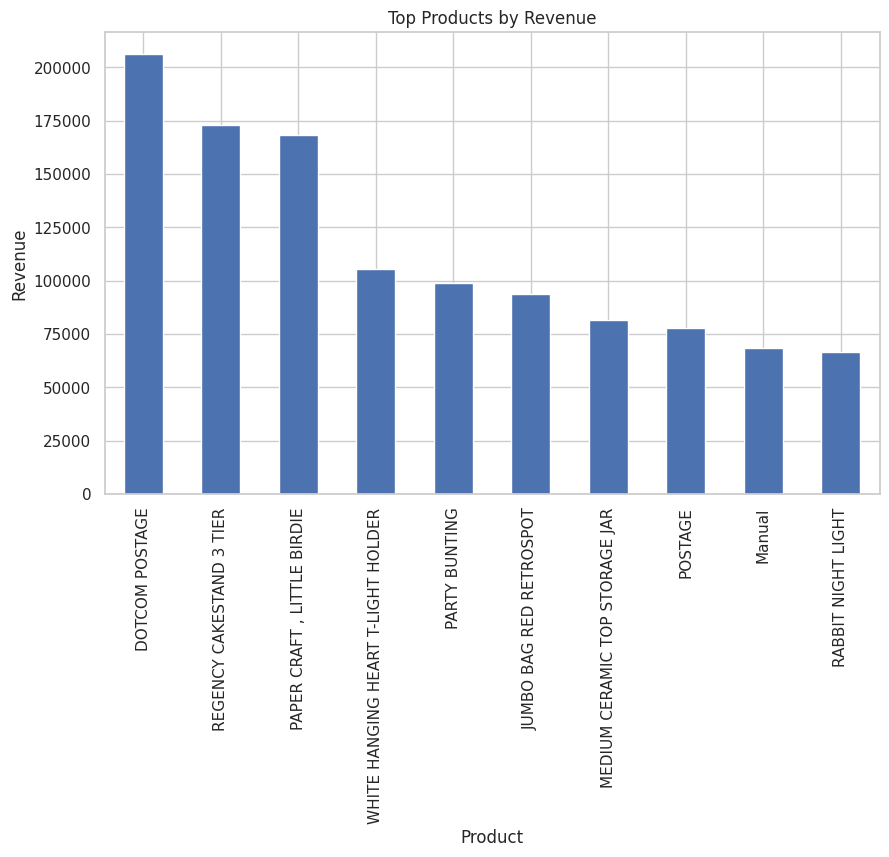

In [142]:
# Top 10 Products by Revenue
top_products = df_full.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

### **Country Analysis**

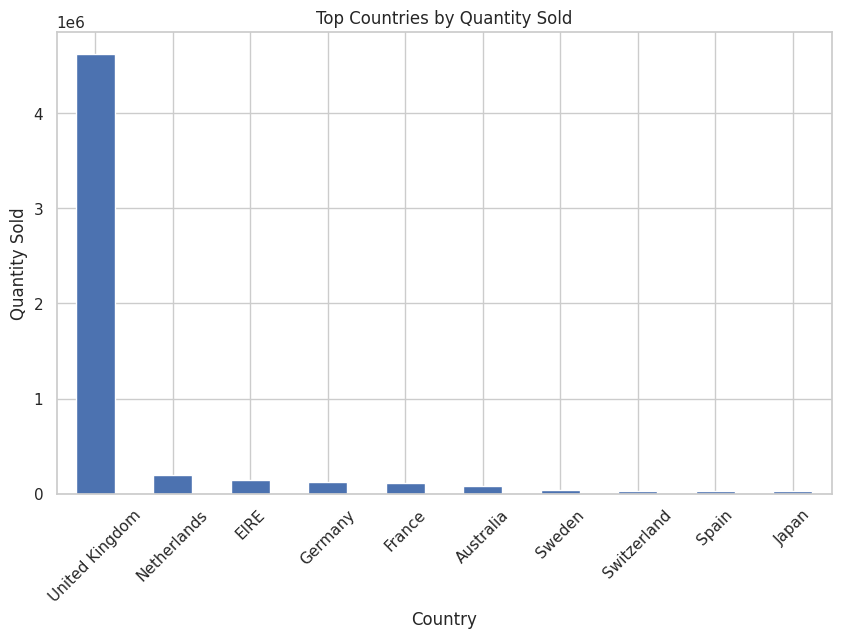

In [143]:
# Top 10 Countries by Quantity
country_rev = df_full.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(10)

country_rev.plot(kind='bar')
plt.title("Top Countries by Quantity Sold")
plt.xlabel("Country")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

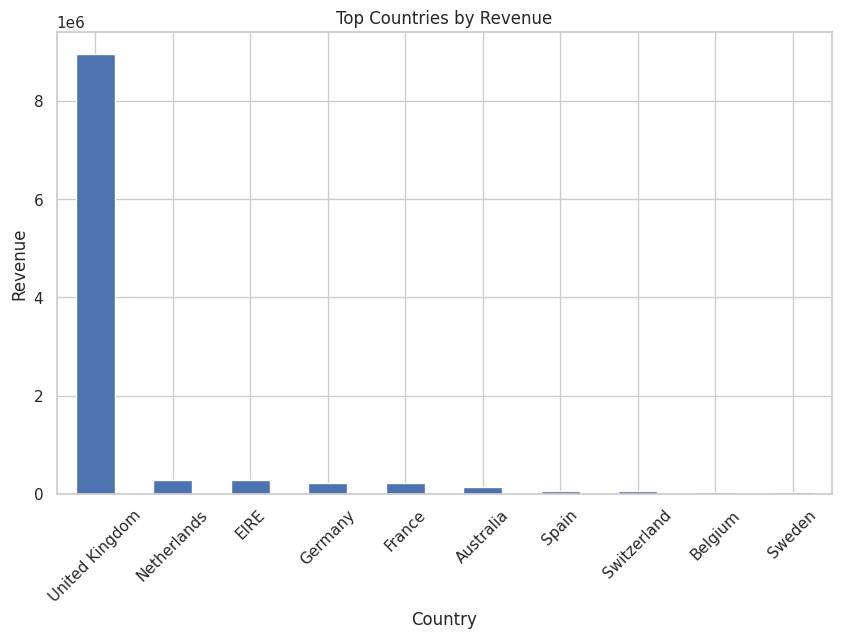

In [144]:
# Top 10 Countries by Revenue
country_rev = df_full.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

country_rev.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### **Customer Analysis**

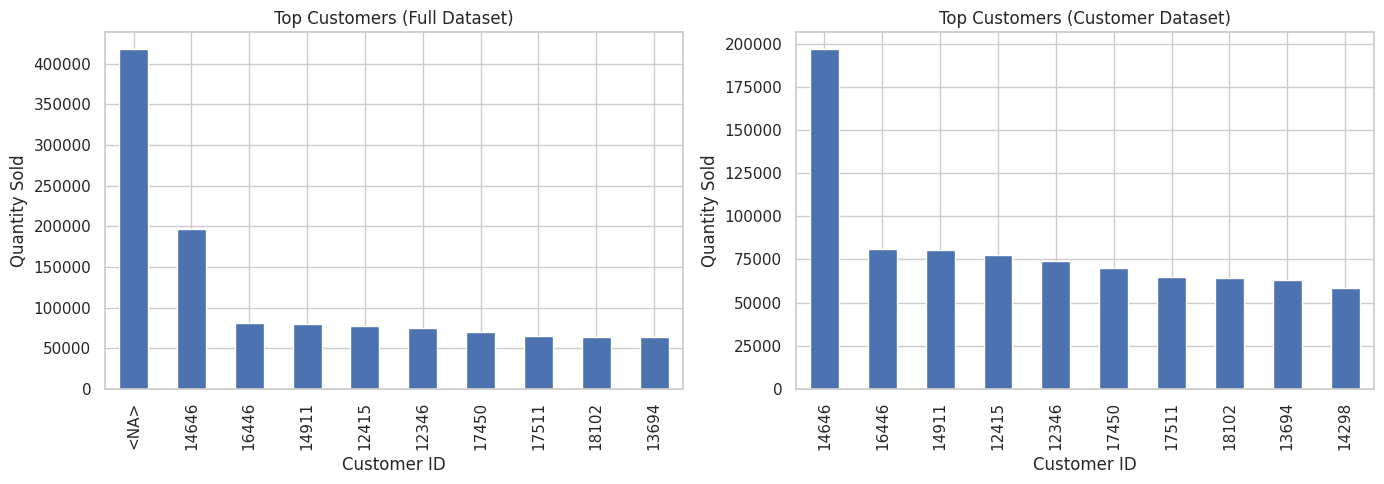

In [145]:
# Top 10 Customers by Quantity

# Top 10 customers from FULL dataset (will ignore missing CustomerID automatically)
top_customers_full = (
    df_full[df_full['Customer ID'].notna()]
    .groupby('Customer ID')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Top 10 customers from CUSTOMER dataset (already cleaned)
top_customers_customer = (
    df_customers.groupby('Customer ID')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot side-by-side
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# FULL DATASET
top_customers_full.plot(kind='bar', ax=axes[0])
axes[0].set_title("Top Customers (Full Dataset)")
axes[0].set_xlabel("Customer ID")
axes[0].set_ylabel("Quantity Sold")

# CUSTOMER DATASET
top_customers_customer.plot(kind='bar', ax=axes[1])
axes[1].set_title("Top Customers (Customer Dataset)")
axes[1].set_xlabel("Customer ID")
axes[1].set_ylabel("Quantity Sold")

plt.tight_layout()
plt.show()

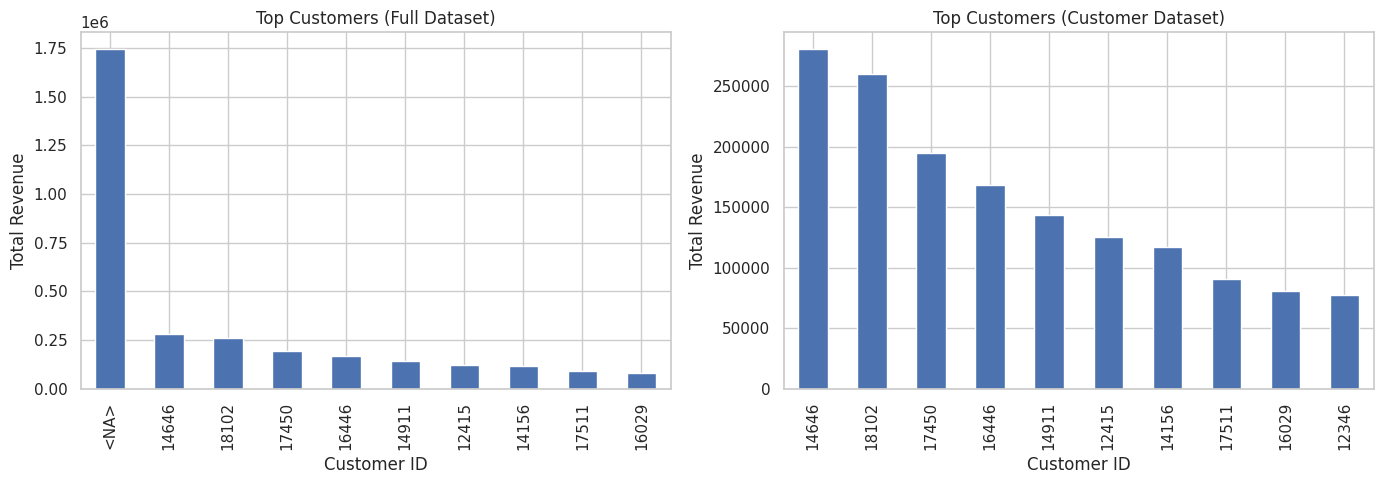

In [146]:
# Top 10 Customers by Revenue

# Top 10 customers from FULL dataset (will ignore missing CustomerID automatically)
top_customers_full = (
    df_full[df_full['Customer ID'].notna()]
    .groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Top 10 customers from CUSTOMER dataset (already cleaned)
top_customers_customer = (
    df_customers.groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot side-by-side
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# FULL DATASET
top_customers_full.plot(kind='bar', ax=axes[0])
axes[0].set_title("Top Customers (Full Dataset)")
axes[0].set_xlabel("Customer ID")
axes[0].set_ylabel("Total Revenue")

# CUSTOMER DATASET
top_customers_customer.plot(kind='bar', ax=axes[1])
axes[1].set_title("Top Customers (Customer Dataset)")
axes[1].set_xlabel("Customer ID")
axes[1].set_ylabel("Total Revenue")

plt.tight_layout()
plt.show()

Repeat Customers: 2845
One-time Customers: 1493


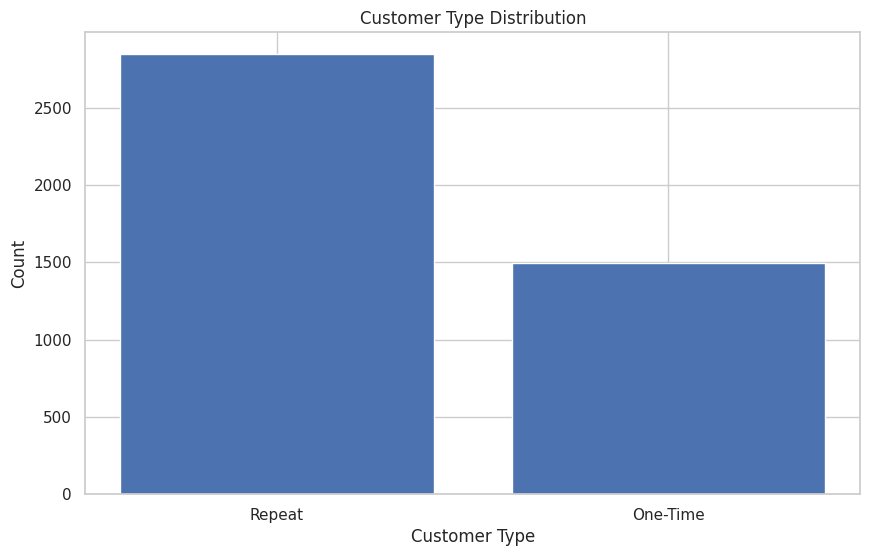

In [147]:
# Customer Type (Repeat vs One-time)

customer_orders = df_customers.groupby('Customer ID')['Invoice No'].nunique()

# Classification
repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

print("Repeat Customers:", repeat_customers)
print("One-time Customers:", one_time_customers)

# Plot

labels = ['Repeat', 'One-Time']
values = [repeat_customers, one_time_customers]

plt.bar(labels, values)

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Count")

plt.show()

### **RFM Analysis**

In [148]:
import datetime as dt

snapshot = df_customers['Invoice Date'].max() + dt.timedelta(days=1)

rfm = df_customers.groupby('Customer ID').agg({
    'Invoice Date': lambda x: (snapshot - x.max()).days,
    'Invoice No': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

# RFM Scores
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm[['R','F','M']].astype(str).sum(axis=1)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score
Customer ID,,,,,,,
12346,326,1,77183.60,1,1,4,114
12347,2,7,4310.00,4,4,4,444
12348,75,4,1595.64,2,3,3,233
12349,19,1,1757.55,3,1,4,314
12350,310,1,334.40,1,1,2,112


### **Cohort Analysis**

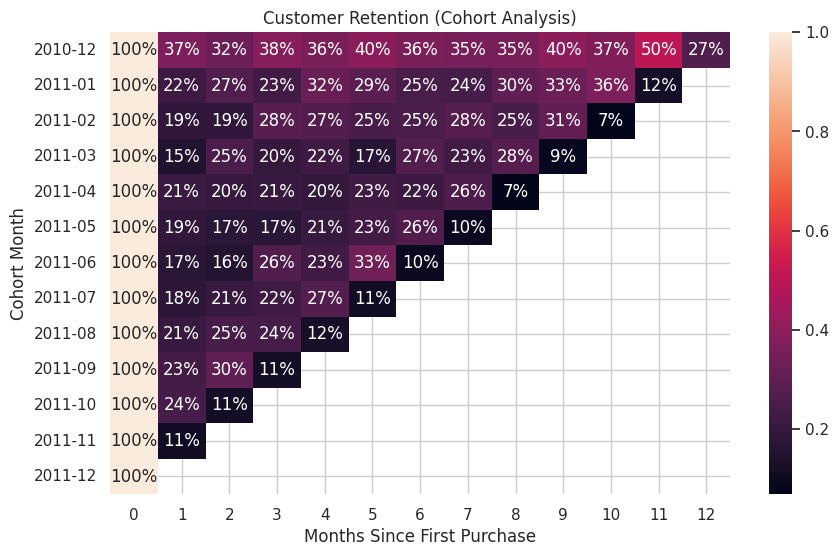

In [149]:
df_customers['InvoiceMonth'] = df_customers['Invoice Date'].dt.to_period('M')
df_customers['CohortMonth'] = df_customers.groupby('Customer ID')['Invoice Date'].transform('min').dt.to_period('M')

df_customers['CohortIndex'] = (df_customers['InvoiceMonth'] - df_customers['CohortMonth']).apply(lambda x: x.n)

# Cohort Table
cohort = df_customers.groupby(['CohortMonth','CohortIndex'])['Customer ID'].nunique().reset_index()

cohort_pivot = cohort.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)

sns.heatmap(retention, annot=True, fmt=".0%")
plt.title("Customer Retention (Cohort Analysis)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

### **CLV Analysis**

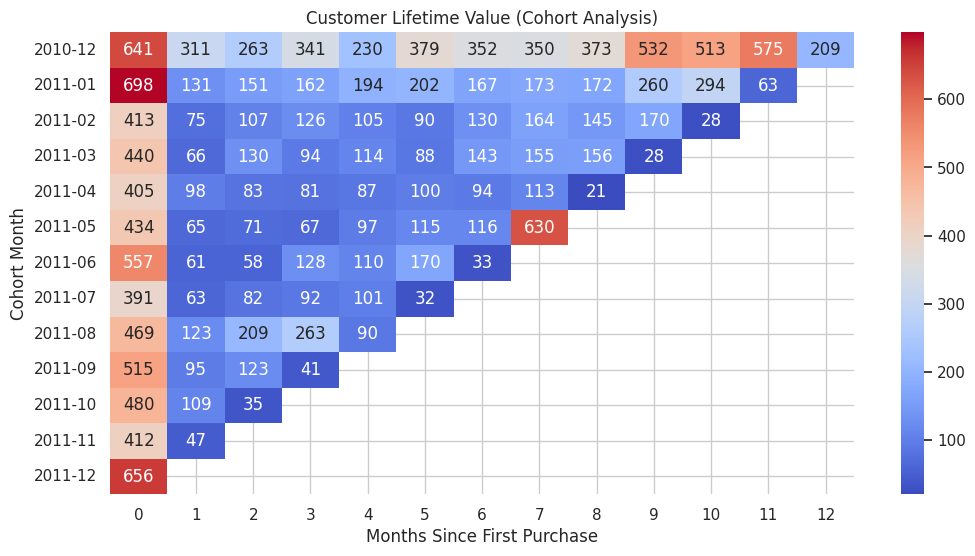

In [150]:
# Customer Lifetime Value (CLV) using Cohort

# Step 1: Monthly Revenue per Customer

df_customers['Revenue'] = df_customers['Quantity'] * df_customers['Unit Price']

monthly_revenue = df_customers.groupby(
    ['CohortMonth', 'CohortIndex']
)['Revenue'].sum().reset_index()

# Step 2: Pivot Table (Revenue Cohort)

revenue_pivot = monthly_revenue.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Revenue'
)

revenue_pivot

# Step 3: Average Revenue per Customer (CLV Approx)

# Number of customers in each cohort
cohort_size = cohort_pivot.iloc[:,0]

# Divide revenue by number of customers
clv = revenue_pivot.divide(cohort_size, axis=0)

clv

# Step 4: Visualize CLV

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(clv, annot=True, fmt=".0f", cmap='coolwarm')

plt.title("Customer Lifetime Value (Cohort Analysis)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

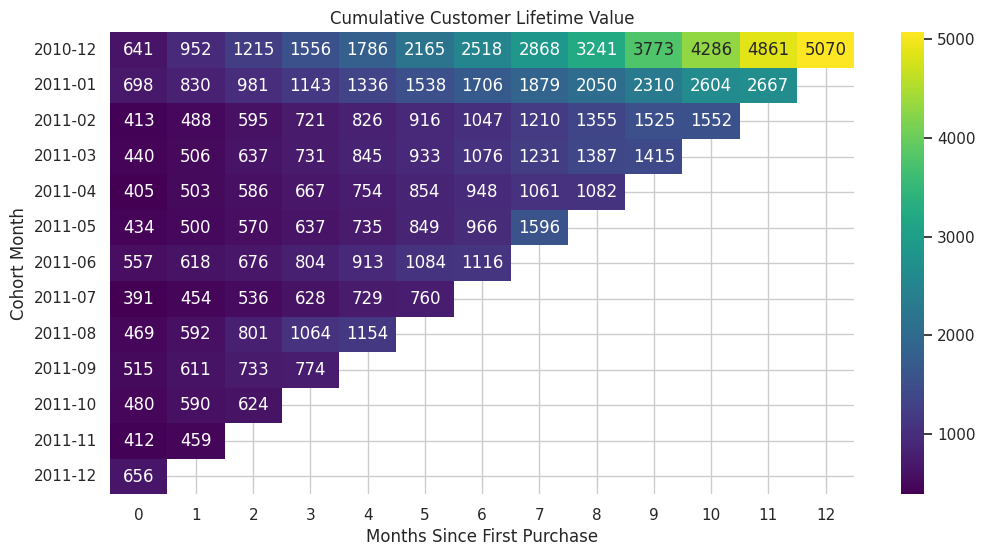

In [151]:
# Cumulative CLV

clv_cumulative = clv.cumsum(axis=1)

plt.figure(figsize=(12,6))
sns.heatmap(clv_cumulative, annot=True, fmt=".0f", cmap='viridis')

plt.title("Cumulative Customer Lifetime Value")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

### **Final Summary and Comparison Table**

In [152]:
# Final Summary and Comparison Table

full_data_total_rows = df_full.shape[0]
full_data_total_transactions = df_full['Invoice No'].nunique()
full_data_unique_customers = df_full['Customer ID'].nunique()
full_data_unique_products = df_full['Stock Code'].nunique()
full_data_countries = df_full['Country'].nunique()
full_data_total_revenue = df_full['Revenue'].sum()
full_data_average_order_value = df_full.groupby('Invoice No')['Revenue'].sum().mean()
full_data_total_quantity_sold = df_full['Quantity'].sum()
full_data_avg_quantity_per_order = full_data_total_quantity_sold / full_data_total_transactions
full_data_top_country_revenue = df_full.groupby('Country')['Revenue'].sum().idxmax()
full_data_top_product_quantity = df_full.groupby('Description')['Quantity'].sum().idxmax()
full_data_peak_sales_day = df_full.groupby('DayOfWeek', observed=False)['Revenue'].sum().idxmax()
full_data_peak_sales_hour = df_full.groupby('Hour', observed=False)['Revenue'].sum().idxmax()

# Customer Data Metrics
customer_data_total_rows = df_customers.shape[0]
customer_data_total_transactions = df_customers['Invoice No'].nunique()
customer_data_unique_customers = df_customers['Customer ID'].nunique()
customer_data_unique_products = df_customers['Stock Code'].nunique()
customer_data_countries = df_customers['Country'].nunique()
customer_data_total_revenue = df_customers['Revenue'].sum()
customer_data_average_order_value = df_customers.groupby('Invoice No')['Revenue'].sum().mean()
customer_data_total_quantity_sold = df_customers['Quantity'].sum()
customer_data_avg_quantity_per_order = customer_data_total_quantity_sold / customer_data_total_transactions
customer_data_top_country_revenue = df_customers.groupby('Country')['Revenue'].sum().idxmax()
customer_data_top_product_quantity = df_customers.groupby('Description')['Quantity'].sum().idxmax()
customer_data_top_customer_revenue = df_customers.groupby('Customer ID')['Revenue'].sum().idxmax()
customer_data_peak_sales_day = df_customers.groupby('DayOfWeek', observed=False)['Revenue'].sum().idxmax()
customer_data_peak_sales_hour = df_customers.groupby('Hour', observed=False)['Revenue'].sum().idxmax()

# Create the detailed summary table
detailed_summary_table = pd.DataFrame({
    'Metric': [
        'Total Rows',
        'Total Transactions',
        'Unique Customers',
        'Unique Products',
        'Countries',
        'Total Revenue',
        'Average Order Value',
        'Total Quantity Sold',
        'Average Quantity per Order',
        'Repeat Customers',
        'One-time Customers',
        'Top Country by Revenue',
        'Top Product by Quantity',
        'Top Customer by Revenue',
        'Peak Sales Day',
        'Peak Sales Hour'
    ],
    'Full Data': [
        full_data_total_rows,
        full_data_total_transactions,
        full_data_unique_customers,
        full_data_unique_products,
        full_data_countries,
        f'{full_data_total_revenue:,.2f}',
        f'{full_data_average_order_value:,.2f}',
        f'{full_data_total_quantity_sold:,.0f}',
        f'{full_data_avg_quantity_per_order:,.2f}',
        'N/A', # Not directly applicable in the same way as Customer Data
        'N/A', # Not directly applicable in the same way as Customer Data
        full_data_top_country_revenue,
        full_data_top_product_quantity,
        'N/A', # Best derived from Customer Data for accuracy
        full_data_peak_sales_day,
        full_data_peak_sales_hour
    ],
    'Customer Data': [
        customer_data_total_rows,
        customer_data_total_transactions,
        customer_data_unique_customers,
        customer_data_unique_products,
        customer_data_countries,
        f'{customer_data_total_revenue:,.2f}',
        f'{customer_data_average_order_value:,.2f}',
        f'{customer_data_total_quantity_sold:,.0f}',
        f'{customer_data_avg_quantity_per_order:,.2f}',
        f'{repeat_customers:,.0f}',
        f'{one_time_customers:,.0f}',
        customer_data_top_country_revenue,
        customer_data_top_product_quantity,
        customer_data_top_customer_revenue,
        customer_data_peak_sales_day,
        customer_data_peak_sales_hour
    ]
})

print("Detailed Summary and Comparison Table:")
display(detailed_summary_table)

Detailed Summary and Comparison Table:


,Metric,Full Data,Customer Data
0,Total Rows,519589,387844
1,Total Transactions,19959,18531
2,Unique Customers,4339,4338
3,Unique Products,3922,3665
4,Countries,38,37
5,Total Revenue,"10,587,081.94","8,844,544.40"
6,Average Order Value,530.44,477.28
7,Total Quantity Sold,"5,546,556","5,128,601"
8,Average Quantity per Order,277.90,276.76
9,Repeat Customers,N/A,"2,845"


### **Saving Datasets**

In [153]:
# Saving as CSV

# Save full dataset
df_full.to_csv('online_retail_full.csv', index=False)

# Save customer dataset
df_customers.to_csv('online_retail_customer.csv', index=False)

# Downloading to my system (from Colab)

from google.colab import files

files.download('online_retail_full.csv')
files.download('online_retail_customer.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>